Установка нужных библиотек

In [ ]:
!pip install networkx matplotlib pandas

Перемещение датасета в нужную папку

In [ ]:
import os
import shutil

os.makedirs("data", exist_ok=True)

shutil.move(
    "dataset_sandbox_type2.json",
    "data/dataset_sandbox_type2.json"
)

print("Готово")
print("Файлы в корне:", os.listdir("."))
print("Файлы в data:", os.listdir("data"))

Готово
Файлы в корне: ['.config', 'dataset.py', 'genetic_solver_min.py', 'data', 'genetic_solver_components_new.py', 'sample_data']
Файлы в data: ['dataset_sandbox_type2.json']


Проверка структуры папок и файлов

In [ ]:
import os

assert os.path.exists("dataset.py"), "Нет dataset.py"
assert os.path.exists("genetic_solver_components_new.py"), "Нет simple_solver_components.py"
assert os.path.exists("genetic_solver_min.py"), "Нет simple_solver_min.py"
assert os.path.exists("data/dataset_sandbox_type2.json"), "Нет data/dataset_sandbox_type2.json"

print("Все нужные файлы на месте")

Все нужные файлы на месте


**Решение с помощью генетического алгоритма** для 1 дня (80 хромосом, 300 поколений)

In [ ]:
from pathlib import Path
from genetic_solver_min import MultiDaySandboxRunner

BASE_DATASET_PATH = Path("data/dataset_sandbox_type2.json")
OUTPUT_ROOT = Path("genetic_runtime_outputs")

runner = MultiDaySandboxRunner(BASE_DATASET_PATH, OUTPUT_ROOT)

results = runner.run(
    days=1,
    seed=42,
    mass_noise=0.0,
    render_first_day=True
)

for r in results:
    print(r)

DayResult(day_index=1, solver_status='feasible', assigned_routes=18, unassigned_tasks=0, active_agents=14, transport_work_ton_km=148.075, all_checks_ok=True, output_dir=PosixPath('genetic_runtime_outputs/day_001'))


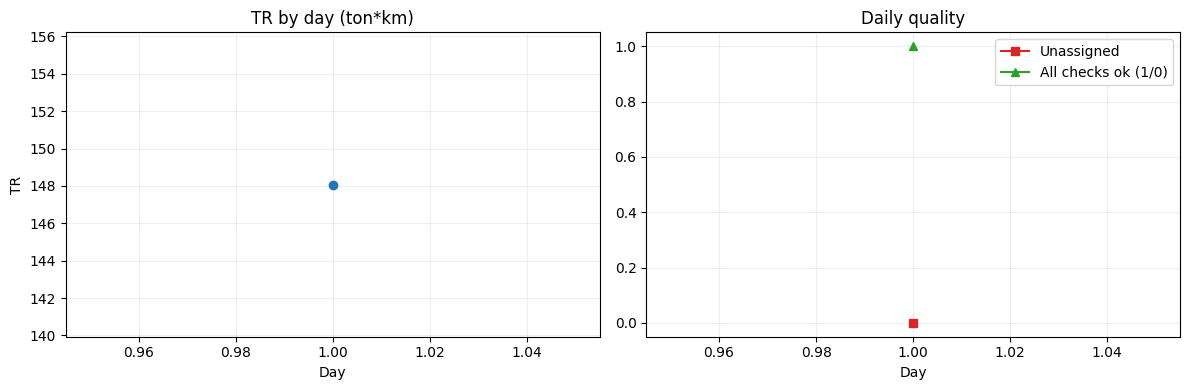

In [9]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

days = [r.day_index for r in results]
tr = [r.transport_work_ton_km or 0.0 for r in results]
unassigned = [r.unassigned_tasks for r in results]
checks = [1 if r.all_checks_ok else 0 for r in results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(days, tr, marker="o", color="#1f77b4")
axes[0].set_title("TR by day (ton*km)")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("TR")
axes[0].grid(alpha=0.2)

axes[1].plot(days, unassigned, marker="s", color="#d62728", label="Unassigned")
axes[1].plot(days, checks, marker="^", color="#2ca02c", label="All checks ok (1/0)")
axes[1].set_title("Daily quality")
axes[1].set_xlabel("Day")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()

Day 1 map: genetic_runtime_outputs/day_001/solution_map.png


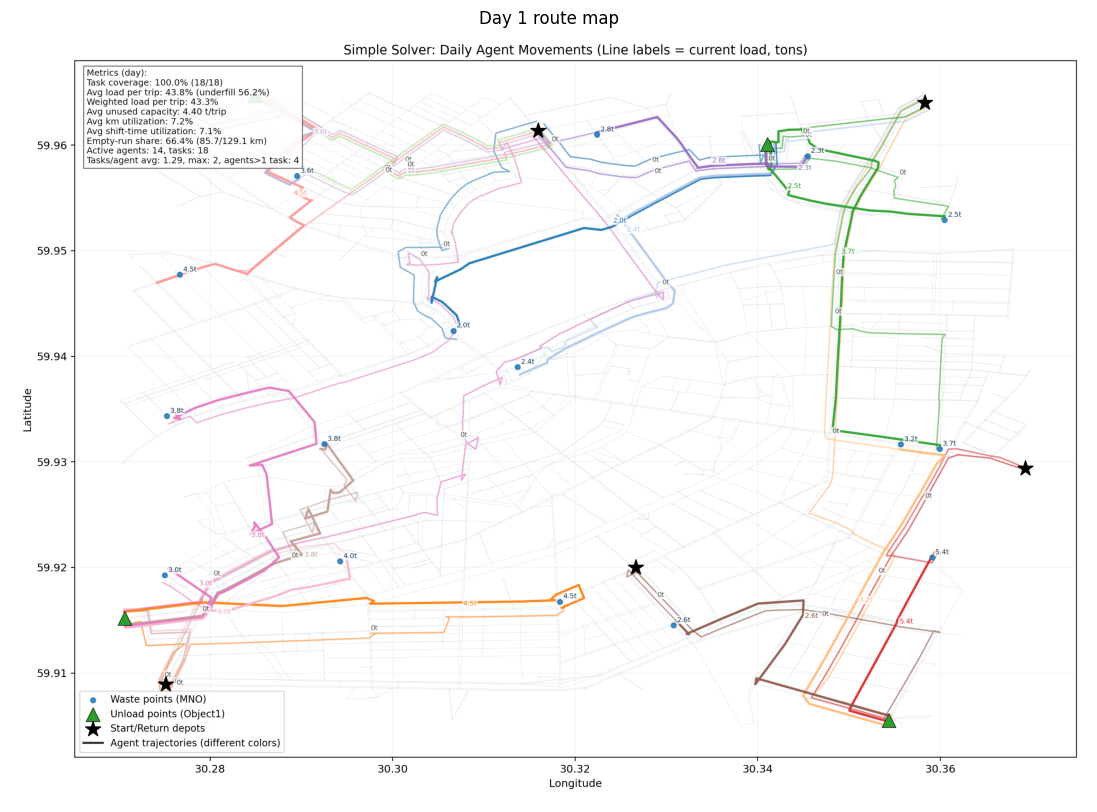

In [10]:
day1_map = OUTPUT_ROOT / "day_001" / "solution_map.png"
print("Day 1 map:", day1_map)

img = mpimg.imread(day1_map)
plt.figure(figsize=(14, 10))
plt.imshow(img)
plt.axis("off")
plt.title("Day 1 route map")
plt.show()